In [327]:
import sys; sys.path.append('../..')
from abslithist import *
from abslithist.llms import *

In [328]:
LLM_STASH

Config,Param,Value
Path,Root Dir,/Users/ryan/github/abslithist/data/stash/llms
,Filename,data.db
Engine,Engine,pairtree
,Serializer,hashstash
,Compress,lz4
,B64,True
Stats,Len,188


In [329]:
def load_results(stash, model=DEFAULT_MODEL):
    id2data = defaultdict(list)
    for k,v in tqdm(stash.items(), total=len(stash)):
        if k['model'] != model:
            continue

        v = parse_json_str(v)
        if v:
            slice_txts = k['user_prompt'].split('#########\n\n')[1:]
            if len(slice_txts) != len(v):
                print(f"Warning: {k['text_id']} has {len(slice_txts)} slices but {len(v)} results")
                continue
            for txt,v_i in zip(slice_txts,v):
                v_i['slice_txt'] = txt
                v_i['concabs'] = score_psg(txt)
            id2data[k['text_id']].extend(v)
    return id2data
            

In [330]:
results = load_results(LLM_STASH)
# novel_results = results['Richardson.Pamela']
# novel_results.sort(key=lambda x: x['id'])
# novel_results[0]

 44%|████▍     | 83/188 [00:00<00:00, 226.80it/s]

 89%|████████▉ | 168/188 [00:00<00:00, 262.16it/s]

Error parsing JSON: Expecting value: line 63 column 1 (char 2129)
Error parsing JSON: Expecting value: line 107 column 1 (char 3194)
Error parsing JSON: Expecting ',' delimiter: line 173 column 253 (char 5051)


100%|██████████| 188/188 [00:00<00:00, 235.02it/s]


In [331]:
def compile_dataframe(results, **metadata):
    """
    Compile slice-level JSON results into a flat dataframe.
    
    Returns two dataframes:
    - slices_df: one row per slice (slice-level annotations)
    - chars_df: one row per character-description per slice
      (with slice-level columns duplicated)
    """
    
    slice_rows = []
    char_rows = []
    
    for s in results:
        sid = s['id']
        slice_num = int(sid.split('_')[1])
        
        # Slice-level row
        slice_row = {
            **metadata,
            'slice_id': sid,
            'slice_num': slice_num,
            'slice_concabs': s.get('concabs', None),
            'summary': s.get('summary', ''),
            'narrative_mode': s.get('narrative_mode', ''),
            'concrete_abstract': s.get('concrete_abstract', None),
            'social_space': s.get('social_space', ''),
            'n_char_descriptions': len(s.get('character_descriptions', [])),
            'key_abstractions': s.get('key_abstractions', []),
            'key_concretions': s.get('key_concretions', []),
            'n_abstractions': len(s.get('key_abstractions', [])),
            'n_concretions': len(s.get('key_concretions', [])),
        }
        slice_rows.append(slice_row)
        
        # Character-level rows
        for desc in s.get('character_descriptions', []):
            # Normalize mode to always be a list
            mode = desc.get('mode', [])
            if isinstance(mode, str):
                mode = [mode]
            
            char_row = {
                # Slice-level info (duplicated)
                **metadata,
                'slice_id': sid,
                'slice_num': slice_num,
                'slice_concabs': s.get('concabs', None),
                'narrative_mode': s.get('narrative_mode', ''),
                'concrete_abstract': s.get('concrete_abstract', None),
                'social_space': s.get('social_space', ''),
                
                # Character-level info
                'character': desc.get('name', ''),
                'gender': desc.get('gender', 'unknown'),
                'class': desc.get('class', 'unknown'),
                'described_by': desc.get('described_by', ''),
                'passage': desc.get('passage', ''),
                'descriptors': desc.get('descriptors', []),
                'mode': mode,
                
                # Flattened mode booleans for easy filtering
                'mode_physical': 'physical' in mode,
                'mode_social': 'social' in mode,
                'mode_moral': 'moral' in mode,
                'mode_manner': 'manner' in mode,
                'mode_material': 'material' in mode,
                'mode_relational': 'relational' in mode,
                'mode_behavioral': 'behavioral' in mode,
                
                # Described-by categories
                'by_narrator': desc.get('described_by', '').startswith('narrator'),
                'by_other_char': desc.get('described_by', '').startswith('other_character'),
                'by_collective': desc.get('described_by', '').startswith('collective'),
            }
            char_rows.append(char_row)
    
    slices_df = pd.DataFrame(slice_rows)
    chars_df = pd.DataFrame(char_rows)
    
    return co_presence_ratio(slices_df), first_appearances(chars_df)


def first_appearances(chars_df):
    """
    For each character in each novel, find their first description.
    Everything after is a redescription.
    """
    chars_df = chars_df.copy()
    chars_df = chars_df.sort_values(['novel', 'character', 'slice_num'])
    chars_df['is_introduction'] = ~chars_df.duplicated(
        subset=['novel', 'character'], keep='first'
    )
    return chars_df


def co_presence_ratio(slices_df):
    """
    Compute abstract/concrete co-presence ratio per slice.
    High ratio = both registers loaded (allegorical).
    Low ratio = one register dominates.
    """
    df = slices_df.copy()
    df['co_presence'] = df.apply(
        lambda r: (
            min(r['n_abstractions'], r['n_concretions']) /
            max(r['n_abstractions'], r['n_concretions'])
            if max(r['n_abstractions'], r['n_concretions']) > 0
            else 0
        ),
        axis=1
    )
    return df


In [332]:
# Example: load and compile multiple novels

all_slices = []
all_chars = []

for novel,novel_results in results.items():
    slices_df, chars_df = compile_dataframe(
        novel_results, novel=novel
    )
    all_slices.append(slices_df)
    all_chars.append(chars_df)

slices = pd.concat(all_slices, ignore_index=True)
chars = pd.concat(all_chars, ignore_index=True)

# Add co-presence ratio
slices = co_presence_ratio(slices)

# Mark first appearances vs redescriptions
chars = first_appearances(chars)

# --------------------------------------------------------
# Quick analyses
# --------------------------------------------------------

# Average concreteness per novel
printm("### Average concreteness by novel")
display(slices.groupby('novel')['concrete_abstract'].mean().round(2))

# Narrative mode distribution per novel
printm("### Narrative mode distribution")
display(pd.crosstab(slices['novel'], slices['narrative_mode'], normalize='index').round(2))

# Social space distribution per novel
printm("### Social space distribution")
display(pd.crosstab(slices['novel'], slices['social_space'], normalize='index').round(2))

# Description mode by novel (% of character descriptions that are physical, moral, etc.)
printm("### Description mode by novel")
mode_cols = [c for c in chars.columns if c.startswith('mode_')]
display(chars.groupby('novel')[mode_cols].mean().round(2))

# Described-by source by novel
printm("### Description source by novel")
by_cols = ['by_narrator', 'by_other_char', 'by_collective']
display(chars.groupby('novel')[by_cols].mean().round(2))

# Description mode by class (across all novels)
printm("### Description mode by class")
display(chars.groupby('class')[mode_cols].mean().round(2).sort_values('mode_physical', ascending=False))

# Introductions only: mode by novel
intros = chars[chars['is_introduction']]
printm("### Introduction mode by novel")
display(intros.groupby('novel')[mode_cols].mean().round(2).sort_values('mode_physical', ascending=False))

# Co-presence ratio by novel
printm("### Co-presence ratio by novel")
display(slices.groupby('novel')['co_presence'].mean().round(2))

# Save
# slices.to_csv('results/slices_compiled.csv', index=False)
# chars.to_csv('results/chars_compiled.csv', index=False)
# print("\nSaved to results/slices_compiled.csv and results/chars_compiled.csv")

### Average concreteness by novel

novel
Anon.Lazarillo                                     4.95
Richardson.Pamela                                  3.48
Richardson.Pamela.Vol2                             3.00
chadwyck.Defoe.Moll_Flanders.1021                  3.78
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168    4.51
Name: concrete_abstract, dtype: float64

### Narrative mode distribution

narrative_mode,commentary,description,epistolary,reflection,scenic,summary
novel,,,,,,
Anon.Lazarillo,0.08,0.03,0.00,0.08,0.62,0.20
Richardson.Pamela,0.02,0.00,0.13,0.13,0.63,0.08
Richardson.Pamela.Vol2,0.10,0.02,0.35,0.10,0.34,0.08
chadwyck.Defoe.Moll_Flanders.1021,0.07,0.00,0.00,0.16,0.46,0.31
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,0.03,0.11,0.00,0.06,0.68,0.10


### Social space distribution

...

,mode_physical,mode_social,mode_moral,mode_manner,mode_material,mode_relational,mode_behavioral
class,,,,,,,
institutional,1.00,0.00,0.00,1.00,0.00,0.00,1.00
merchant,0.39,0.19,0.55,0.32,0.03,0.12,0.45
laboring_poor,0.38,0.28,0.55,0.18,0.04,0.14,0.40
unknown,0.35,0.20,0.59,0.20,0.06,0.18,0.47
professional,0.34,0.23,0.52,0.46,0.05,0.14,0.41
aristocracy,0.32,0.18,0.62,0.38,0.03,0.22,0.29
servant,0.32,0.15,0.71,0.24,0.02,0.15,0.30
clergy,0.25,0.20,0.65,0.30,0.02,0.14,0.31
gentry,0.24,0.15,0.73,0.30,0.04,0.18,0.37


### Introduction mode by novel

,mode_physical,mode_social,mode_moral,mode_manner,mode_material,mode_relational,mode_behavioral
novel,,,,,,,
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,0.49,0.24,0.46,0.28,0.08,0.19,0.41
Anon.Lazarillo,0.28,0.27,0.59,0.11,0.09,0.13,0.46
chadwyck.Defoe.Moll_Flanders.1021,0.22,0.36,0.62,0.28,0.07,0.14,0.47
Richardson.Pamela,0.20,0.24,0.72,0.19,0.04,0.11,0.39
Richardson.Pamela.Vol2,0.17,0.24,0.77,0.27,0.03,0.22,0.40


### Co-presence ratio by novel

novel
Anon.Lazarillo                                     0.70
Richardson.Pamela                                  0.80
Richardson.Pamela.Vol2                             0.80
chadwyck.Defoe.Moll_Flanders.1021                  0.86
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168    0.88
Name: co_presence, dtype: float64

In [333]:
chars.groupby(['novel','is_introduction']).mean(numeric_only=True).sort_values('slice_concabs', ascending=False)

slice_num  \
novel                                           is_introduction               
Anon.Lazarillo                                  False             46.468085   
                                                True              51.948276   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 True             279.921971   
                                                False            371.687439   
chadwyck.Defoe.Moll_Flanders.1021               True             118.752294   
                                                False            114.035714   
Richardson.Pamela                               False            205.653409   
                                                True             202.625000   
Richardson.Pamela.Vol2                          True             229.707395   
                                                False            184.044280   

                                                                 slice_concabs  \
novel                                           is_introduction                  
Anon.Lazarillo                                  False                 0.150531   
                                                True                  0.113501   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 True                  0.012886   
                                                False                -0.101374   
chadwyck.Defoe.Moll_Flanders.1021               True                 -0.287738   
                                                False                -0.389074   
Richardson.Pamela                               False                -0.417594   
                                                True                 -0.417765   
Richardson.Pamela.Vol2                          True                 -0.563135   
                                                False                -0.569122   

                                                                 concrete_abstract  \
novel                                           is_introduction                      
Anon.Lazarillo                                  False                     4.468085   
                                                True                      4.827586   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 True                      4.813142   
                                                False                     4.396300   
chadwyck.Defoe.Moll_Flanders.1021               True                      3.834862   
                                                False                     3.728571   
Richardson.Pamela                               False                     3.403409   
                                                True                      3.270833   
Richardson.Pamela.Vol2                          True                      3.073955   
                                                False                     3.086716   

                                                                 mode_physical  \
novel                                           is_introduction                  
Anon.Lazarillo                                  False                 0.361702   
                                                True                  0.275862   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 True                  0.494867   
                                                False                 0.422590   
chadwyck.Defoe.Moll_Flanders.1021               True                  0.220183   
                                                False                 0.207143   
Richardson.Pamela                               False                 0.183239   
                                                True                  0.203125   
Richardson.Pamela.Vol2                          True                  0.173633   
                                                False                 0.191882   

                                                                 mode_social  \
novel                             

In [334]:
tqdm.pandas()

In [335]:
slices.columns

Index(['novel', 'slice_id', 'slice_num', 'slice_concabs', 'summary',
       'narrative_mode', 'concrete_abstract', 'social_space',
       'n_char_descriptions', 'key_abstractions', 'key_concretions',
       'n_abstractions', 'n_concretions', 'co_presence'],
      dtype='object')

In [336]:
chars['descriptors_concabs'] = chars['descriptors'].progress_apply(lambda x: score_psg('\n'.join(x)))

100%|██████████| 3784/3784 [00:00<00:00, 45759.03it/s]


In [338]:
novel_concabs = chars.groupby('novel').slice_concabs.mean().to_dict()
chars['novel_concabs'] = chars['novel'].map(novel_concabs)

In [339]:
odf=chars.groupby(['novel','class']).mean(numeric_only=True).sort_values('descriptors_concabs', ascending=False)[['novel_concabs','descriptors_concabs']]
odf['concabs_diff'] = odf['descriptors_concabs'] - odf['novel_concabs']
# odf.reset_index().sort_values(['novel','concabs_diff'], ascending=False).set_index(['novel','class']).round(2)
odf.sort_values('concabs_diff', ascending=False).round(2)


novel_concabs  \
novel                                           class                          
chadwyck.Defoe.Moll_Flanders.1021               aristocracy            -0.33   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 institutional          -0.06   
Richardson.Pamela                               merchant               -0.42   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 laboring_poor          -0.06   
Anon.Lazarillo                                  merchant                0.12   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 clergy                 -0.06   
                                                unknown                -0.06   
                                                servant                -0.06   
Richardson.Pamela.Vol2                          unknown                -0.57   
chadwyck.Defoe.Moll_Flanders.1021               servant                -0.33   
                                                laboring_poor          -0.33   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 merchant               -0.06   
Richardson.Pamela.Vol2                          gentry                 -0.57   
                                                aristocracy            -0.57   
Anon.Lazarillo                                  gentry                  0.12   
Richardson.Pamela.Vol2                          laboring_poor          -0.57   
Richardson.Pamela                               servant                -0.42   
Anon.Lazarillo                                  unknown                 0.12   
Richardson.Pamela.Vol2                          servant                -0.57   
Richardson.Pamela                               laboring_poor          -0.42   
chadwyck.Defoe.Moll_Flanders.1021               unknown                -0.33   
Anon.Lazarillo                                  laboring_poor           0.12   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 professional           -0.06   
Richardson.Pamela                               unknown                -0.42   
chadwyck.Defoe.Moll_Flanders.1021               gentry                 -0.33   
Richardson.Pamela                               gentry                 -0.42   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 aristocracy            -0.06   
Richardson.Pamela.Vol2                          professional           -0.57   
Richardson.Pamela                               professional           -0.42   
Anon.Lazarillo                                  clergy                  0.12   
                                                servant                 0.12   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 gentry                 -0.06   
chadwyck.Defoe.Moll_Flanders.1021               professional           -0.33   
                                                merchant               -0.33   
Richardson.Pamela                               aristocracy            -0.42   
Richardson.Pamela.Vol2                          clergy                 -0.57   
Richardson.Pamela                               clergy                 -0.42   
chadwyck.Defoe.Moll_Flanders.1021               clergy                 -0.33   
Anon.Lazarillo                                  professional            0.12   
Richardson.Pamela.Vol2                          merchant               -0.57   

                                                               descriptors_concabs  \
novel                                           class                                
chadwyck.Defoe.Moll_Flanders.1021               aristocracy                   0.41   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 institutional                 0.44   
Richardson.Pamela                               merchant                     -0.16   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 laboring_poor                 0.16   
Anon.Lazarillo                                  merchant                      0.31   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 clergy                        0.05   
              

In [340]:
chars.sort_values('descriptors_concabs', ascending=False)[['novel','character','descriptors_concabs','descriptors']].dropna()

,novel,character,descriptors_concabs,descriptors
1296,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,a person in pattens,1.957033,"[in pattens, poking at the child from below with a broom]"
2864,Richardson.Pamela,Pamela,1.706740,[sauce-box]
2814,Richardson.Pamela,Pamela,1.706740,[sauce-box]
3213,Richardson.Pamela,the 'squire,1.660334,[in his morning-gown and slippers]
396,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Michael Jackson,1.632560,"[in a blue welveteen waistcoat, with a double row of mother of pearl buttons]"
...,...,...,...,...
768,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Mr. Tulkinghorn,-1.799733,"[has no political opinions, no opinions]"
2654,Richardson.Pamela,Mr. Williams,-1.815661,"[motivated by virtue, motivated by compassion]"
2252,Richardson.Pamela.Vol2,an irreligious man,-1.815851,[irreligious]
711,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Mr. Smallweed,-1.828928,[conduct does him great honour]


In [341]:
# chars['novel_character'] = chars['novel'] + '__' + chars['character']
# chars_only_once = chars.novel_character.value_counts()
# chars_only_once = chars_only_once[chars_only_once < 3].index.tolist()
# chars_more_than_once = chars.query('~(novel_character in @chars_only_once)')
# chars_more_than_once

In [342]:
# chars_more_than_once.groupby(['novel','character']).descriptors_concabs.mean().sort_values(ascending=False).head(25)

In [343]:
pd.set_option('display.max_colwidth', 200)

In [344]:
def get_chars_more_than_once(chars, only_intros=False):
    from string import punctuation
    chars = chars.copy()
    chars['character'] = chars['character'].apply(lambda x: x.strip(punctuation).title().replace("'S ", "'s "))
    chars['novel_character'] = chars['novel'] + '__' + chars['character']
    chars_only_once = chars.novel_character.value_counts()
    chars_only_once = chars_only_once[chars_only_once < 3].index.tolist()
    chars_more_than_once = chars.query('~(novel_character in @chars_only_once)')
    if only_intros:
        chars_more_than_once = chars_more_than_once.query('is_introduction==True')
    # chars_more_than_once

    chars_more_than_once_by_char = []
    for (novel,char),df in chars_more_than_once.groupby(['novel','character']):
        descs = [x for d in df.descriptors for x in d]
        desc = '\n'.join(descs)
        score = score_psg(desc)
        chars_more_than_once_by_char.append({
            'novel':novel,
            'character':char,
            'class':df.iloc[0]['class'],
            'gender':df.iloc[0]['gender'],
            'descriptors_concabs':score,
            'novel_concabs':novel_concabs[novel],
            'concabs_diff':score - novel_concabs[novel],
            'descriptors':descs,
            'descriptors_num_words': len(desc.split())

        })
    chars_more_than_once_by_char = pd.DataFrame(chars_more_than_once_by_char)
    # chars_more_than_once_by_char.sort_values('concabs_diff', ascending=False).round(2).query('descriptors_num_words >= 10').head(10)
    return chars_more_than_once_by_char

In [345]:
chars_more_than_once_by_char_intros = get_chars_more_than_once(chars, only_intros=True)
chars_more_than_once_by_char = get_chars_more_than_once(chars, only_intros=False)

# chars_more_than_once_by_char_intros.sort_values('concabs_diff', ascending=True).round(2).query('descriptors_num_words >= 10').head(10)

In [346]:
chars_more_than_once_by_char.groupby(['class']).agg({
    'descriptors_concabs':'mean',
    'novel_concabs':'mean',
    'concabs_diff':'mean',
    'descriptors_num_words':'sum',
}).sort_values('concabs_diff', ascending=False)

,descriptors_concabs,novel_concabs,concabs_diff,descriptors_num_words
class,,,,
servant,-0.152297,-0.304853,0.152557,4965
laboring_poor,-0.027595,-0.160832,0.133237,2091
merchant,-0.007855,-0.117170,0.109315,1887
unknown,-0.112987,-0.162232,0.049245,1185
clergy,-0.213347,-0.249917,0.036570,765
gentry,-0.328834,-0.312542,-0.016292,11890
professional,-0.178406,-0.147677,-0.030730,4150
aristocracy,-0.366319,-0.305115,-0.061204,2554


In [347]:
chars_more_than_once_by_char_intros.groupby(['class']).agg({
    'descriptors_concabs':'mean',
    'novel_concabs':'mean',
    'concabs_diff':'mean',
    'descriptors_num_words':'sum',
}).sort_values('concabs_diff', ascending=False)

,descriptors_concabs,novel_concabs,concabs_diff,descriptors_num_words
class,,,,
laboring_poor,0.084693,-0.160832,0.245525,292
merchant,0.120690,-0.117170,0.237860,349
unknown,-0.105298,-0.162232,0.056934,165
gentry,-0.271932,-0.312542,0.040610,1080
servant,-0.294301,-0.304853,0.020562,283
professional,-0.212086,-0.147677,-0.064409,508
clergy,-0.373857,-0.249917,-0.123940,94
aristocracy,-0.600509,-0.305115,-0.295395,317


In [348]:
# chars_more_than_once_by_char.query('descriptors_num_words >= 25').sort_values('descriptors_concabs', ascending=False)[['novel','character','descriptors_concabs','descriptors','descriptors_num_words']].dropna().head(25)

In [349]:
chars_more_than_once_by_char_both = pd.concat([
    chars_more_than_once_by_char_intros.assign(is_intro=True),
    # chars_more_than_once_by_char.assign(is_intro=False),
])
# chars_more_than_once_by_char_both

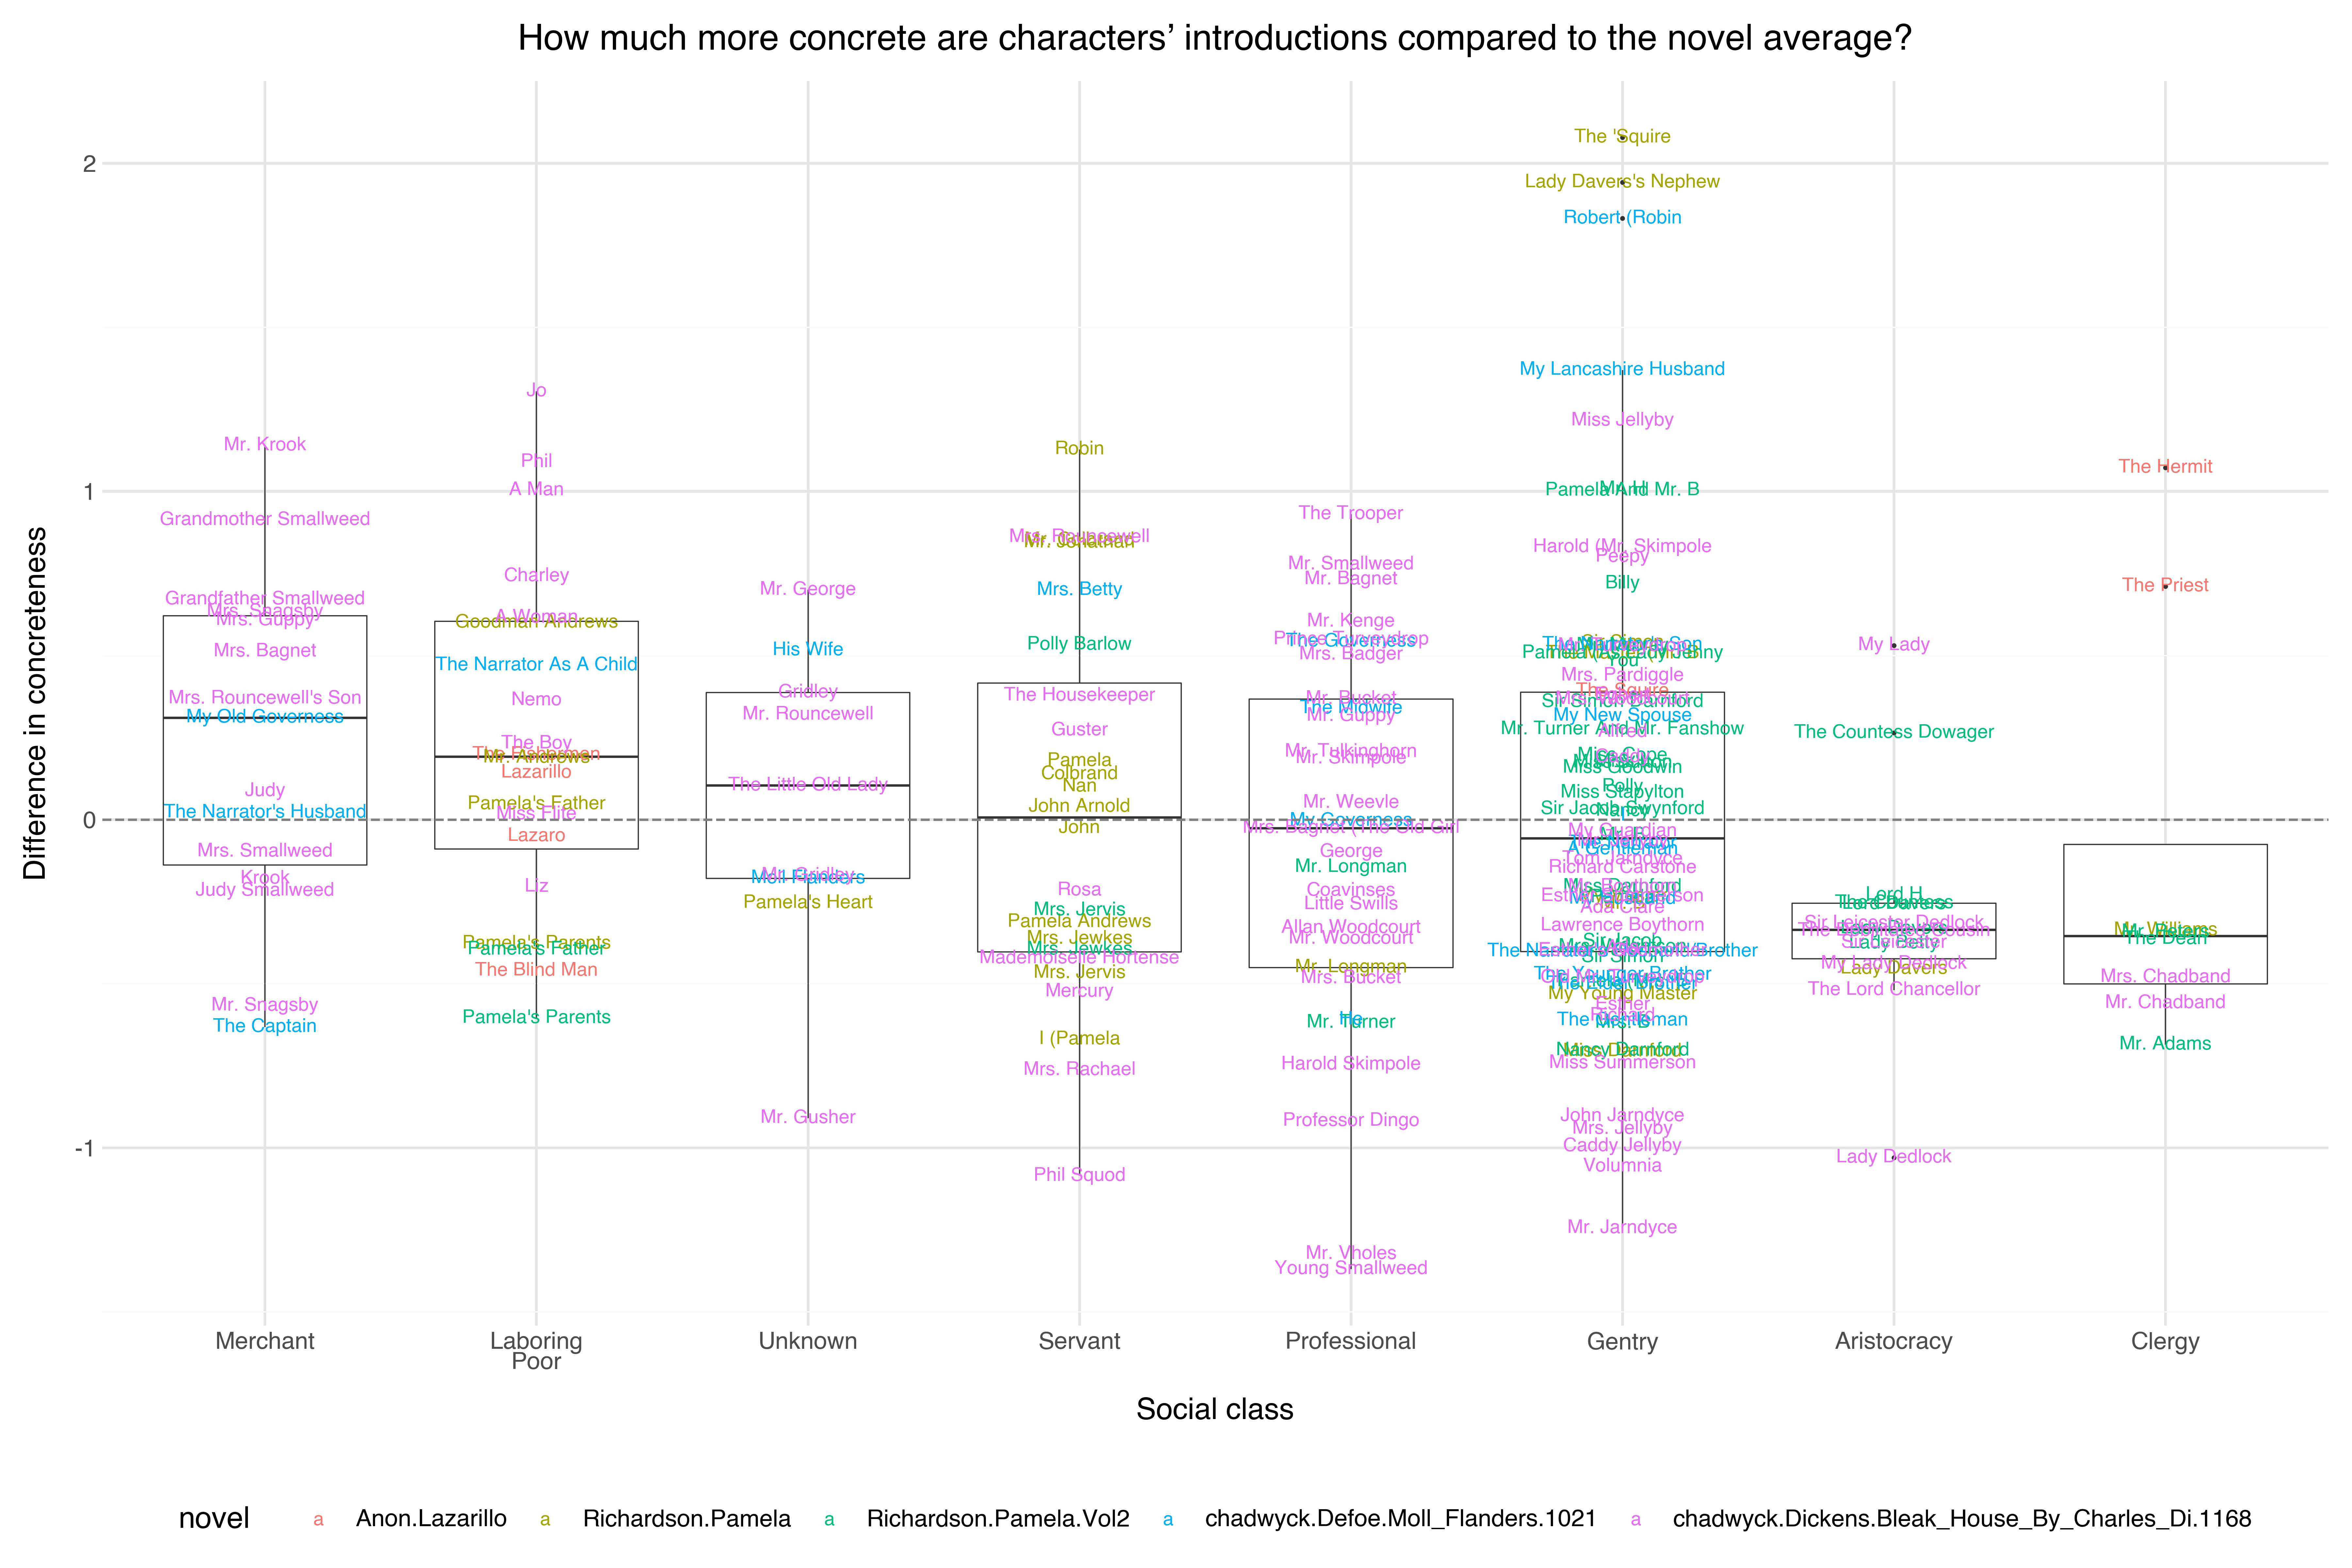

In [350]:
figdf = chars_more_than_once_by_char_both.copy()
figdf['class'] = figdf['class'].apply(lambda x: x.replace("_", "\n").title())
figdf['class'] = pd.Categorical(figdf['class'], categories=figdf.groupby('class').concabs_diff.median().sort_values(ascending=False).index, ordered=True)

fig = (
    p9.ggplot(figdf, p9.aes(x='class', y='concabs_diff',label='character'))
    + p9.geom_boxplot(outlier_size=0, size=.25)
    # + p9.geom_jitter(p9.aes(color='concabs_diff', shape='is_intro'), size=1, alpha=.5)
    + p9.geom_text(p9.aes(color='novel', label='character'), size=7)
    + p9.geom_hline(yintercept=0, color='gray', size=.5, linetype='dashed')
    # + p9.facet_wrap('~novel')
    + p9.theme_minimal()
    + p9.theme(figure_size=(12, 8), dpi=300, legend_position='bottom')#, axis_text_x=p9.element_text(angle=45))
    + p9.labs(
        x='Social class',
        title='How much more concrete are characters’ introductions compared to the novel average?',
        y='Difference in concreteness',
    )
    # + p9.scale_color_gradient(low='blue', high='red')
)
fig

In [215]:
slices.groupby('social_space').slice_concabs.mean().sort_values(ascending=False)

social_space
inter_social          -0.079385
natural               -0.155800
public_social         -0.156931
institutional         -0.176508
domestic_unfamiliar   -0.217519
domestic_familiar     -0.276048
indeterminate         -0.530277
Name: slice_concabs, dtype: float64

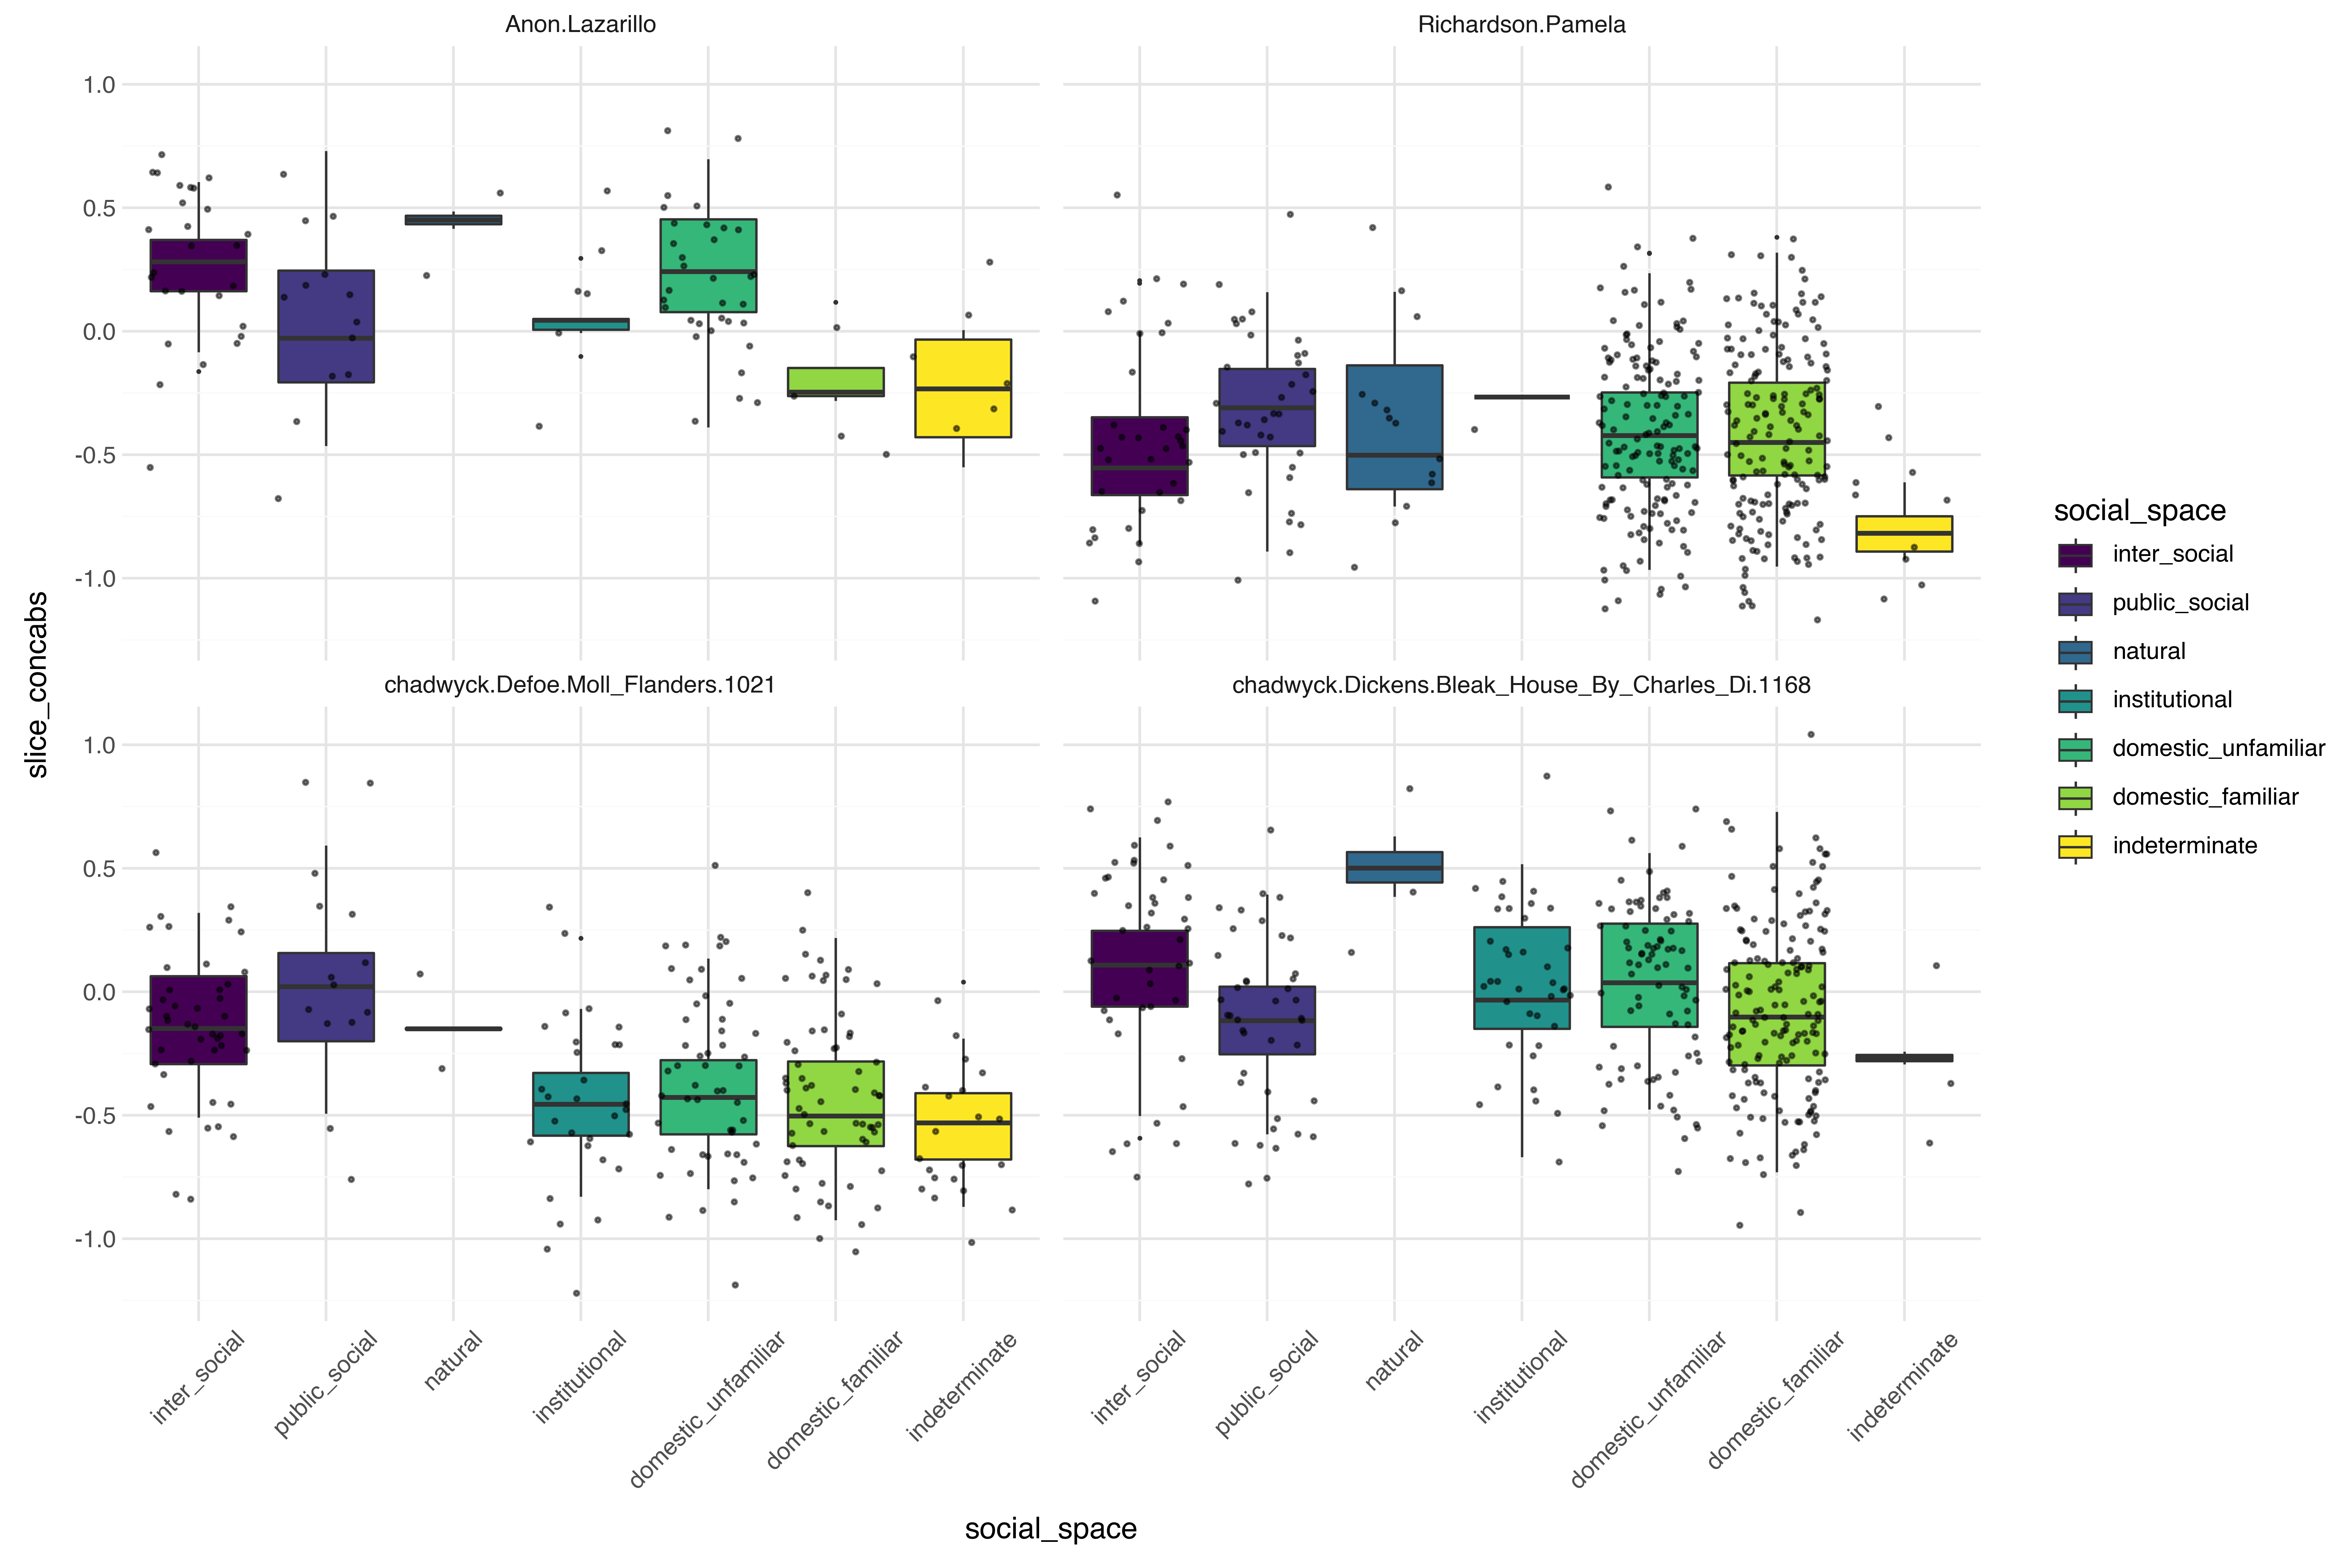

In [247]:
figdf = slices.copy()
figdf['social_space'] = pd.Categorical(figdf['social_space'], categories=slices.groupby('social_space').slice_concabs.median().sort_values(ascending=False).index, ordered=True)
fig = (
    p9.ggplot(figdf, p9.aes(x='social_space', y='slice_concabs'))
    + p9.geom_boxplot(p9.aes(fill='social_space'),outlier_size=0)
    + p9.geom_jitter(size=.5, alpha=.5)
    + p9.facet_wrap('~novel')
    + p9.theme_minimal()
    + p9.theme(figure_size=(12, 8), dpi=300, axis_text_x=p9.element_text(angle=45))
)
fig

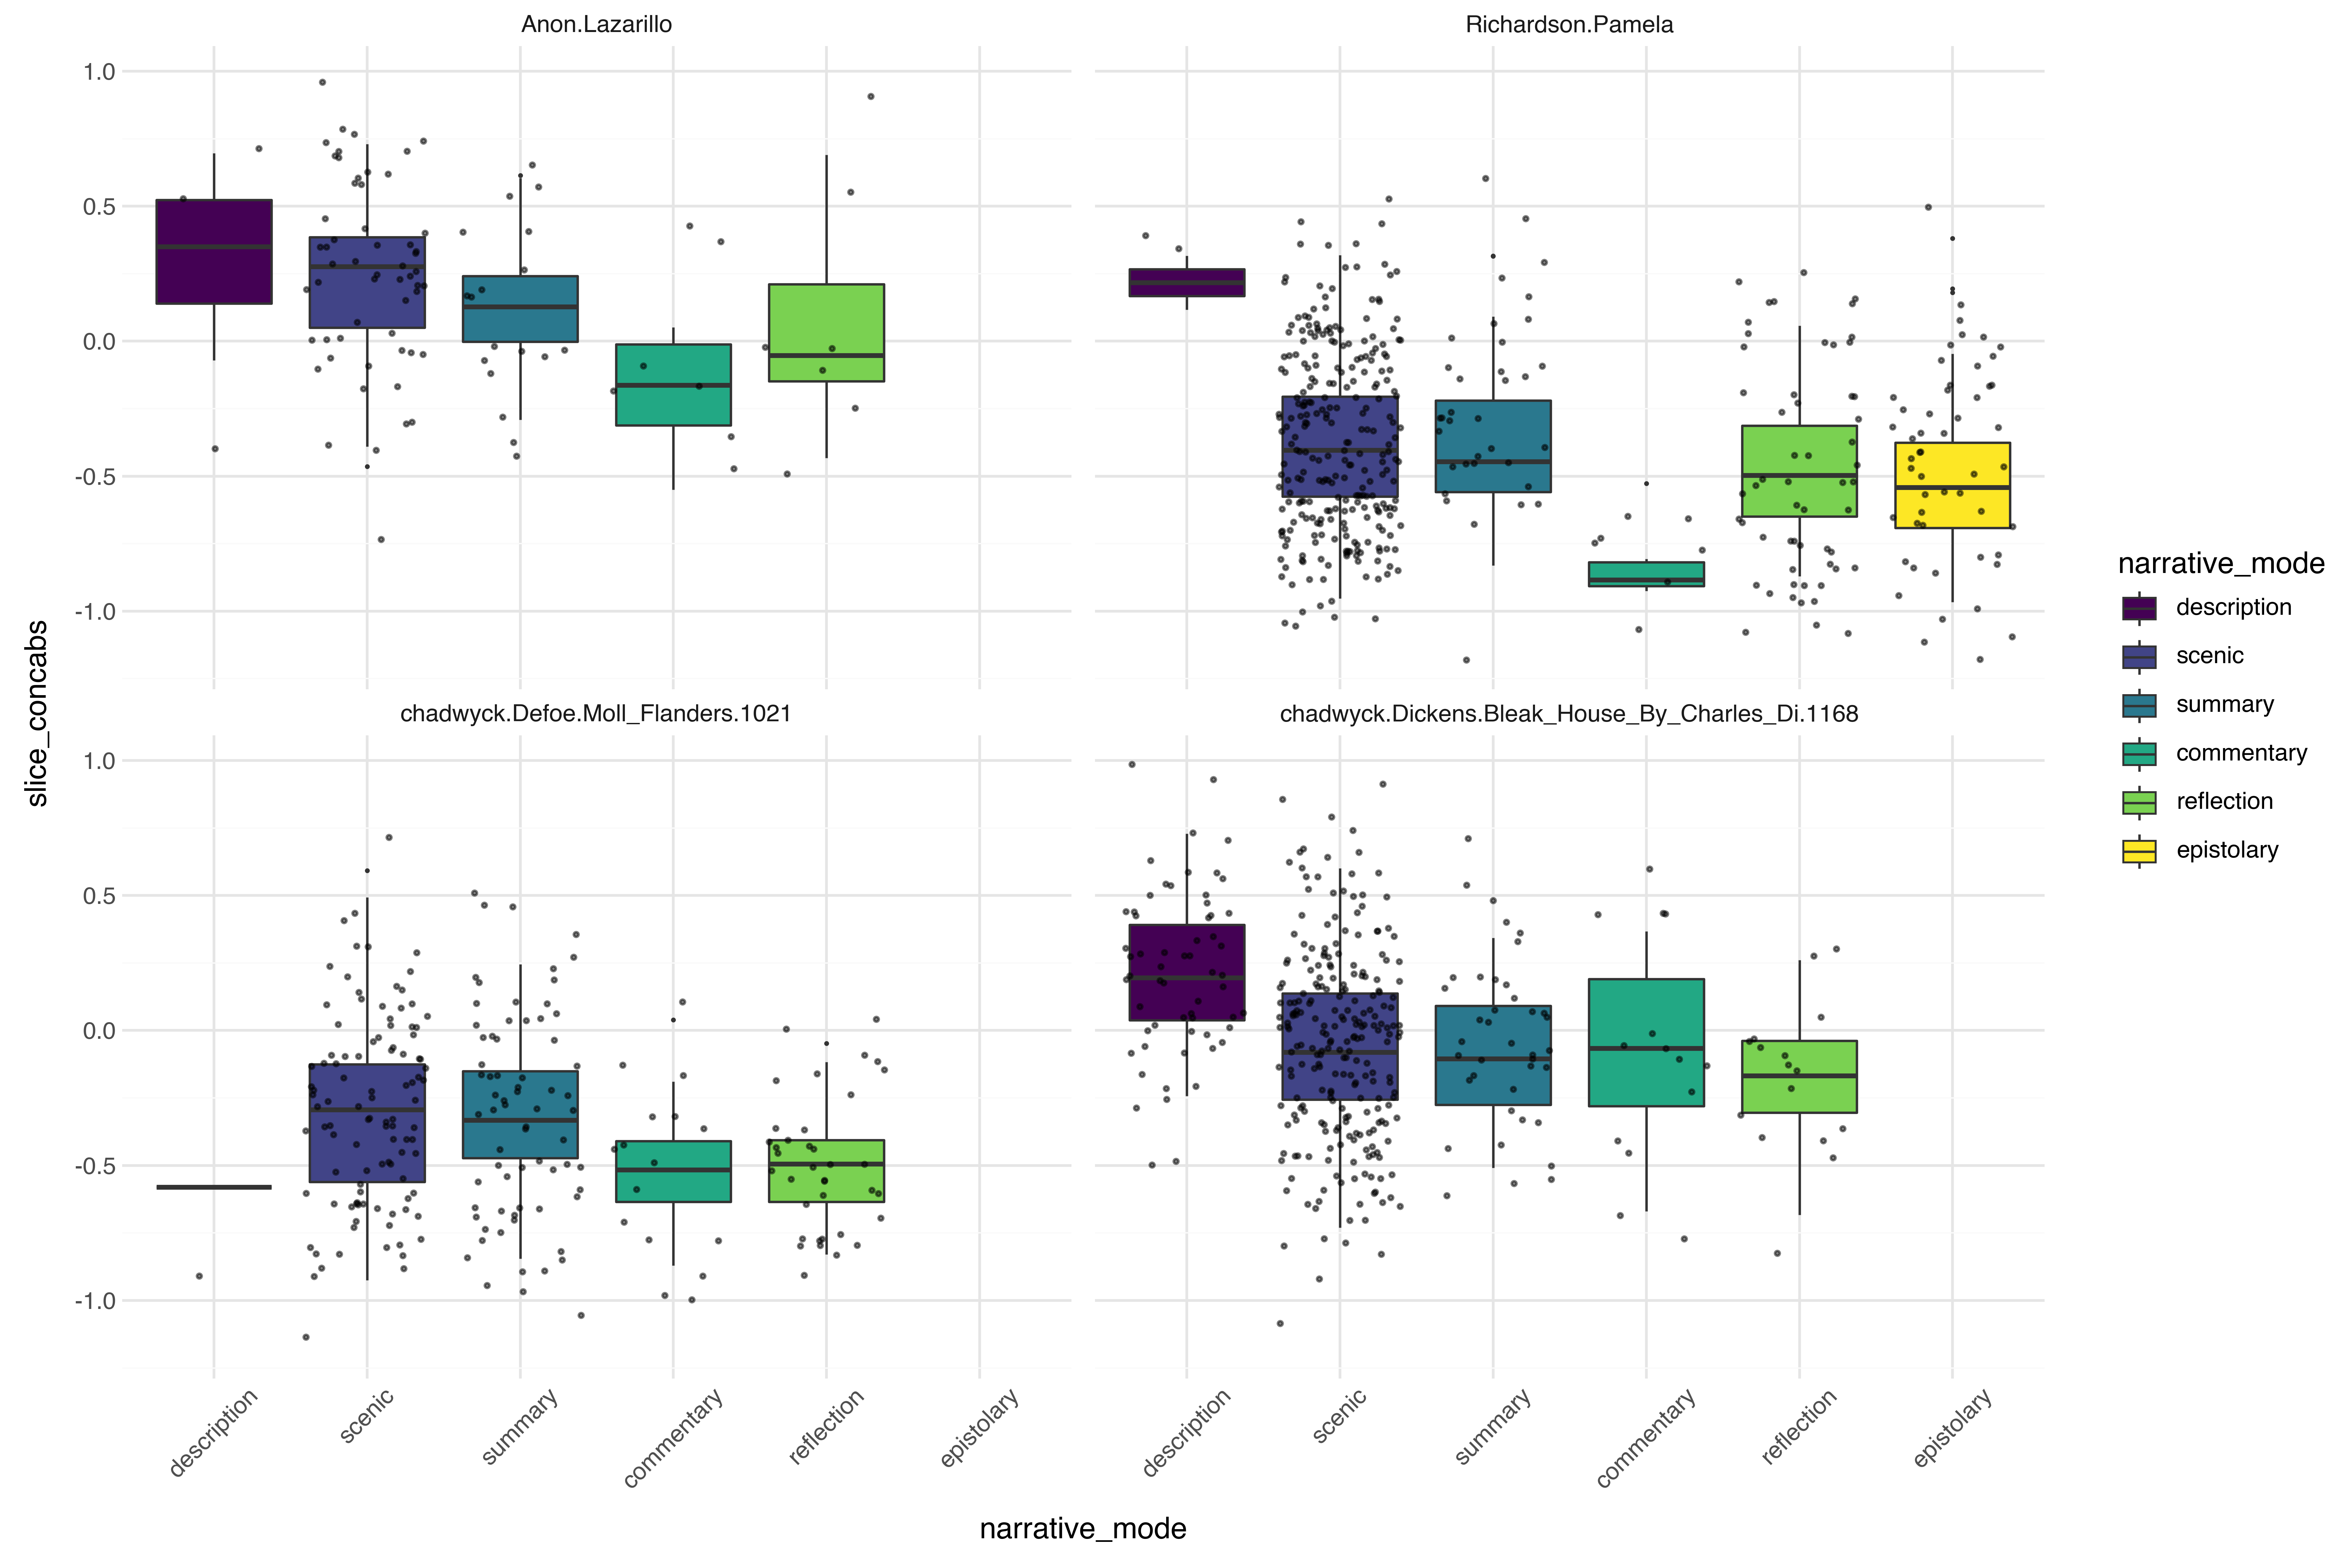

In [248]:
figdf = slices.copy()
figdf['narrative_mode'] = pd.Categorical(figdf['narrative_mode'], categories=slices.groupby('narrative_mode').slice_concabs.median().sort_values(ascending=False).index, ordered=True)
fig = (
    p9.ggplot(figdf, p9.aes(x='narrative_mode', y='slice_concabs'))
    + p9.geom_boxplot(p9.aes(fill='narrative_mode'),outlier_size=0)
    + p9.geom_jitter(size=.5, alpha=.5)
    + p9.facet_wrap('~novel')
    + p9.theme_minimal()
    + p9.theme(figure_size=(12, 8), dpi=300, axis_text_x=p9.element_text(angle=45))
)
fig

In [250]:
chars_more_than_once_by_char

,novel,character,class,gender,descriptors_concabs,novel_concabs,concabs_diff,descriptors,descriptors_num_words
0,Anon.Lazarillo,Lazarillo,laboring_poor,male,0.266211,0.124179,0.142033,"[lazy, no-good sponger]",3
1,Anon.Lazarillo,Lazaro,laboring_poor,male,0.072847,0.124179,-0.051332,[pretty clever],2
2,Anon.Lazarillo,the blind man,laboring_poor,male,-0.336691,0.124179,-0.460869,"[dirty, made up jokes, had a gift for telling the future]",11
3,Anon.Lazarillo,the hermit,clergy,male,1.195869,0.124179,1.071690,"[venerable, white-bearded, with his staff and a rosary]",8
4,Anon.Lazarillo,the priest,clergy,male,0.834325,0.124179,0.710146,"[had all the miserliness in the world, born that way, came along with his priest's frock]",16
...,...,...,...,...,...,...,...,...,...
128,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,my Lady Dedlock,aristocracy,female,-0.555044,-0.031852,-0.523192,"[had not even family, had beauty, pride, ambition, insolent resolve, and sense, exhausted composure, worn-out placidity, equanimity of fatigue, perfectly well bred, a fine face, improved into clas...",36
129,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,old Mr. Turveydrop,gentry,male,-0.624927,-0.031852,-0.593075,"[a very gentlemanly man, celebrated, almost everywhere, for his Deportment, a widower]",12
130,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,the Lord Chancellor,aristocracy,male,-0.584092,-0.031852,-0.552240,"[gave me an indulgent look, acknowledged my curtsey very graciously, with more ease and less ceremony, knew how to go straight to the candor of a boy, dismissed us pleasantly, affable and polite]",33
131,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,the little old lady,unknown,female,0.039484,-0.031852,0.071336,"[curtseying and smiling, with her yesterday's air of patronage]",9
